**Why choosing a Pretrained DenseNet ?**

The project design is a comparison on the Chest X-ray dataset, evaluating:

- the lightweight custom architecture derived from Yen & Tsao (2024) (implemented by Luca), and
- the pretrained DenseNet-121 from TorchXRayVision with weights="densenet121-res224-all" (implemented by Marina).

In this notebook we propose the second model.

A pretrained model is a neural network whose weights have already been optimized on large-scale datasets, providing a strong initialization for downstream tasks. Specifically, we used a pretrained DenseNet backbone and re-purpose it for **binary classification**, producing a discrete label **0/1** for the two target classes (**PNEUMONIA vs NORMAL**).

The transfer-learning pipeline consists of loading the pretrained feature extractor and replacing the original classifier with a task-specific head (binary output).
The backbone is kept fixed (non-trainable) and only the new classification head is optimized.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rm -rf /content/chest_xray
!cp -r "/content/drive/MyDrive/CellData/chest_xray" "/content/chest_xray"
!ls /content/chest_xray


test  train


Torchxrayvision is an open source software library for working with chest X-ray datasets and deep learning models. It provides a common interface and common pre-processing chain for a wide set of publicly available chest X-ray datasets; pre-trained models which are trained on large cohorts of data and enables rapid analysis of large datasets.

Citation: Cohen, J. P., Viviano, J. D., Bertin, P., Morrison, P., Torabian, P., Guarrera, M.,
Lungren, M. P., Chaudhari, A., Brooks, R., Hashir, M., & Bertrand, H. (2021).
TorchXRayVision: A library of chest X-ray datasets and models.
arXiv:2111.00595. https://doi.org/10.48550/arXiv.2111.00595

In [ ]:
! pip install torchxrayvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 33.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Subset
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as T #trasfroma un'immagine PIl in un tensore pytorch. Esempi di trasformazioni tipiche: resize, centercrop, randomflip to tensor normalize ecc... .
from PIL import Image #libreria Python per lavorare con le immagini: aprirle, convertire formato e canali, convertire in grayscale, fare resize ecc... .
import torchxrayvision as xrv
import os
import time
from collections import Counter
import math
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, f1_score, matthews_corrcoef, classification_report, roc_auc_score, average_precision_score
import seaborn as sns

### Training configuration and environment setup

Batch size is the number of training samples processed in one forward pass plus one backward pass, so, the optimizer updates the weights after seeing 32 images. Since the steps per epoch is given by the number of training samples over the number of epochs, incrising the batch size means haveing fewer steps per epoch; increasing the epochs means more passes over data. The batch size is mainly limited by memory so the largest batch size that fit without hit the "out of memory" has been picked.

Resizing to 224×224 means that every input image is converted to a fixed shape of 224 pixels in height and 224 pixels in width before being fed into the model. This is to give a consistent tensor shape, making all the dataset images of the same size.

The learning rate is set to 1e-3 because we are training only the classifier head while keeping the pretrained feature extractor fixed; only a small number of parameters are being optimized.

The number of training epochs is limited to 10 because the backbone of the network is frozen (convergence is much faster).



In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
IMG_SIZE = 224
LR = 1e-3
EPOCHS = 10

train_dir = "/content/chest_xray/train"
test_dir  = "/content/chest_xray/test"


In [ ]:
print("CUDA available:", torch.cuda.is_available())
print("DEVICE:", DEVICE)
print("Current device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
DEVICE: cuda
Current device: Tesla T4


**Check the dataset**

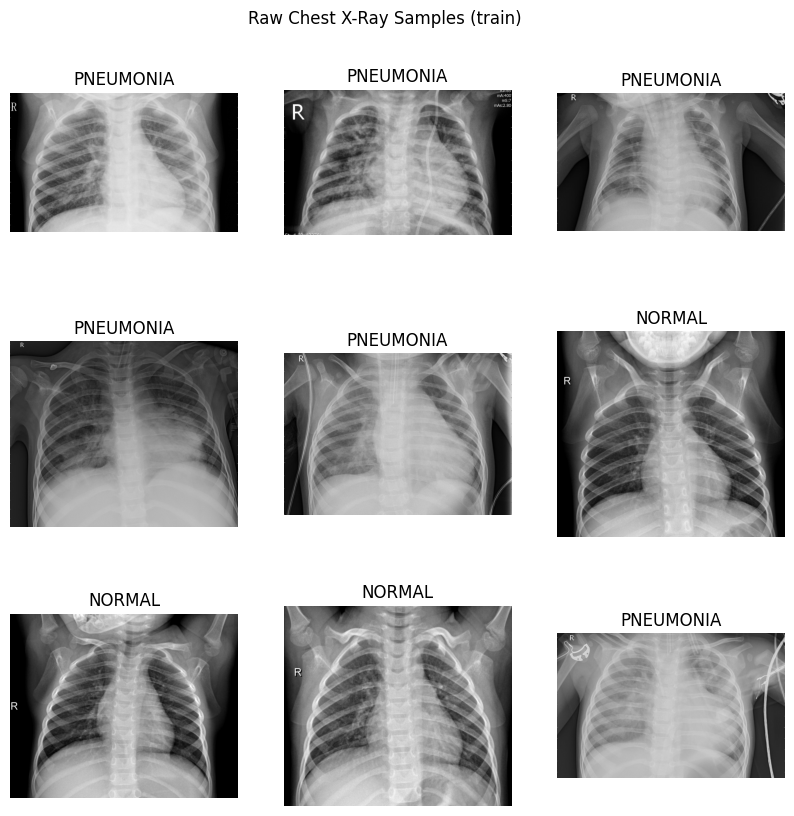

In [ ]:
class_names = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

img_paths, img_labels = [], []
for cls in class_names:
    cls_dir = os.path.join(train_dir, cls)
    for fn in os.listdir(cls_dir):
        if fn.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
            img_paths.append(os.path.join(cls_dir, fn))
            img_labels.append(cls)

np.random.seed(42)
sel = np.random.choice(len(img_paths), size=9, replace=False)

plt.figure(figsize=(10, 10))
for i, j in enumerate(sel, 1):
    img = Image.open(img_paths[j])
    plt.subplot(3, 3, i)
    plt.imshow(img, cmap="gray")
    plt.title(img_labels[j])
    plt.axis("off")
plt.suptitle("Raw Chest X-Ray Samples (train)", y=0.92)
plt.show()


XRVTransform is a callable image preprocessing pipeline.
It encapsulates all preprocessing steps required to transform a raw input image into a tensor in the exact format expected by the model. We use a callable, configured object for preprocessing.

In [ ]:
class XRVTransform:
    def __init__(self, size=224):
        self.size = size
        self.to_tensor = T.ToTensor()
        self.center_crop = xrv.datasets.XRayCenterCrop()
        self.resizer = xrv.datasets.XRayResizer(size)

    def __call__(self, img: Image.Image):
        img = img.convert("L")              # grayscale
        x = self.to_tensor(img)             # [1,H,W] in [0,1]
        x = x * 255.0
        x = xrv.datasets.normalize(x.numpy(), 255)  # [-1024,1024]
        x = self.center_crop(x)
        x = self.resizer(x)
        x = torch.from_numpy(x).float()     # [1,224,224]
        return x

transform = XRVTransform(size=IMG_SIZE)


ImageFolder is a ready-made PyTorch dataset class provided by torchvision.datasets. It loads images from disk and automatically assign labels based on folder structure; turning a directory of images into a labeled dataset usable by a PyTorch DataLoader.

In [ ]:
train_ds = ImageFolder(train_dir, transform=transform)
test_ds  = ImageFolder(test_dir,  transform=transform)

print("Class mapping:", train_ds.class_to_idx)

Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


### Dataset splitting and DataLoader construction

The training dataset is randomly shuffled and split into training and validation subsets using an 80/20 ratio. Every run with the same SEED produces the same split train/validation makeing the benchmark reproducible. The training set is used to learn model parameters, the validation set to tune hyperparameters and prevent overfitting, and the test set to provide a final performance estimate on unseen data.


In [ ]:
N = len(train_ds)
SEED = 42


rng = np.random.default_rng(SEED)
idx = rng.permutation(N)

val_frac = 0.2
n_val = int(val_frac * N)

val_idx = idx[:n_val]
tr_idx  = idx[n_val:]

train_sub = Subset(train_ds, tr_idx)
val_sub   = Subset(train_ds, val_idx)

train_loader = DataLoader(train_sub, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_sub,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,    batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [ ]:
#paths/labels in dataset order (same order as test_loader because shuffle=False)
test_paths = np.array([p for (p, y) in test_ds.samples])
test_true_from_ds = np.array([y for (p, y) in test_ds.samples])


In [ ]:
print("Train:", len(train_sub))
print("Val:", len(val_sub))
print("Test:", len(test_ds))


Train: 4204
Val: 1050
Test: 624


Verify that one single sample coming out of train_ds is exactly in the format expected by the model.

In [ ]:
x, y = train_ds[0]

print("Shape:", x.shape)
print("Min / Max:", x.min().item(), x.max().item())
print("Label:", y)



Shape: torch.Size([1, 224, 224])
Min / Max: -1024.0 843.9750366210938
Label: 0


##Backbone instantiation and configuration
Here we instantiates a DenseNet-121 architecture from the TorchXRayVision (xrv) library. The weights "densenet121-res224-all" indicate pretrained on large-scale chest X-ray datasets, trained with 224×224 input resolution. This backbone acts as a feature extractor, not a classifier. We move the backbone’s parameters and buffers to the selected compute device so that input tensors and model weights are on the same device. We switch the backbone to evaluation mode disableing batch normalization updates, dropout randomness and gradient computation for all backbone parameters. Since the backbone is frozen, we want its behavior to remain deterministic and identical to pretraining, letting it acts as a fixed feature extractor.
Then we defined a costum Pytorch module to reuses the pretrained backbone and add a task specific binary classification head.

In [ ]:

backbone = xrv.models.DenseNet(weights="densenet121-res224-all")
backbone = backbone.to(DEVICE)
backbone.eval()


for p in backbone.parameters():
    p.requires_grad = False


class CXRBinaryModel(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        # DenseNet121 has 1024 exiting channels in the final feature map
        self.fc = nn.Linear(1024, 1)

    def forward(self, x):
        feats = self.backbone.features(x)
        feats = self.pool(feats).squeeze(-1).squeeze(-1)
        logit = self.fc(feats).squeeze(1)
        return logit

model = CXRBinaryModel(backbone).to(DEVICE)

If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt -O /root/.torchxrayvision/models_data/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt`
[██████████████████████████████████████████████████]


Check if it is going to train only the classifier head and not touching the pretrained backbone; iterating over all parameters registered in the model and printing only those that will receive gradient updates during backpropagation.

In [ ]:
print("Trainable parameters:")
for name, p in model.named_parameters():
    if p.requires_grad:
        print(name)


Trainable parameters:
fc.weight
fc.bias


In [ ]:
t0 = time.time()
xb, yb = next(iter(train_loader))
print("Batch in", round(time.time()-t0,2), "sec", xb.shape)


Batch in 1.6 sec torch.Size([32, 1, 224, 224])


In [ ]:
print("Train images:", len(train_ds))
print("Steps per epoch:", len(train_loader))
print("Batch size:", train_loader.batch_size)


Train images: 5254
Steps per epoch: 132
Batch size: 32


**Training**

Class imbalance was handled via BCEWithLogitsLoss(pos_weight), computed from the training subset label counts; in our split Nneg​/Npos​&lt;1,
Optimization uses Adam (lr=1e-3) on the classifier head (model.fc) only, keeping the pretrained DenseNet backbone frozen. The learning-rate scheduler (ReduceLROnPlateau) and early stopping monitor the validation loss, and the final checkpoint corresponds to the epoch with the lowest val_loss. Performance is also reported with MCC computed from epoch-level TP/TN/FP/FN counts at a fixed threshold of 0.5.


In [ ]:
def mcc_from_counts(tp, tn, fp, fn):
    denom = (tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)
    if denom == 0:
        return 0.0
    return (tp*tn - fp*fn) / math.sqrt(denom)

In [ ]:
def run_epoch(loader, train=True, log_every=50, thr=0.5):
    if train:
        model.train()
        model.backbone.eval()
    else:
        model.eval()

    total_loss, total = 0.0, 0
    tp = tn = fp = fn = 0
    t0 = time.time()

    with torch.set_grad_enabled(train):
        for i, (x, y) in enumerate(loader, 1):
            x = x.to(DEVICE)
            y = y.float().to(DEVICE)

            logits = model(x)
            loss = criterion(logits, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            total += x.size(0)

            probs = torch.sigmoid(logits)
            preds = (probs >= thr).long()
            y_int = y.long()

            tp += ((preds == 1) & (y_int == 1)).sum().item()
            tn += ((preds == 0) & (y_int == 0)).sum().item()
            fp += ((preds == 1) & (y_int == 0)).sum().item()
            fn += ((preds == 0) & (y_int == 1)).sum().item()

            if i % log_every == 0:
                elapsed = time.time() - t0
                mcc = mcc_from_counts(tp, tn, fp, fn)
                print(
                    f"{'train' if train else 'eval'} batch {i}/{len(loader)} "
                    f"loss {loss.item():.4f} mcc {mcc:.4f} "
                    f"elapsed {elapsed/60:.1f} min"
                )

    epoch_mcc = mcc_from_counts(tp, tn, fp, fn)
    return total_loss / total, epoch_mcc


Counter extracts the class label of the i-th image, collects all labels belonging to that split and counts how many samples belong to each class in the that set. So the output tells us how balanced the split is. Here we check class counts and percentages for train_sub.

In [ ]:
train_labels = [train_sub.dataset.samples[i][1] for i in train_sub.indices]
c = Counter(train_labels)
c0, c1 = c[0], c[1]
print("Train_sub label counts:", c)


pos_weight_value = c0 / c1
pos_weight_value = max(1.0, pos_weight_value)
pos_weight = torch.tensor([pos_weight_value], device=DEVICE)
print("pos_weight used:", pos_weight.item())

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LR)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-6
)

best_val_loss = float("inf")
patience = 5
bad_epochs = 0
best_state = None

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_mcc = run_epoch(train_loader, train=True,  log_every=50, thr=0.5)
    va_loss, va_mcc = run_epoch(val_loader,   train=False, log_every=50, thr=0.5)

    scheduler.step(va_loss)

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} mcc {tr_mcc:.4f} | "
          f"val loss {va_loss:.4f} mcc {va_mcc:.4f} | lr {lr_now:.2e}")

    if va_loss < best_val_loss - 1e-4:
        best_val_loss = va_loss
        bad_epochs = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
            break

model.load_state_dict(best_state)
model.to(DEVICE)
print("Loaded best model state (by val_loss).")


Train_sub label counts: Counter({1: 3130, 0: 1074})
pos_weight used: 1.0
train batch 50/132 loss 0.1595 mcc 0.8499 elapsed 1.4 min
train batch 100/132 loss 0.0724 mcc 0.8482 elapsed 2.7 min
Epoch 01 | train loss 0.1677 mcc 0.8495 | val loss 0.1500 mcc 0.8472 | lr 1.00e-03
train batch 50/132 loss 0.1343 mcc 0.8778 elapsed 1.3 min
train batch 100/132 loss 0.1010 mcc 0.8868 elapsed 2.6 min
Epoch 02 | train loss 0.1251 mcc 0.8834 | val loss 0.1212 mcc 0.8802 | lr 1.00e-03
train batch 50/132 loss 0.0525 mcc 0.8888 elapsed 1.3 min
train batch 100/132 loss 0.1214 mcc 0.8829 elapsed 2.7 min
Epoch 03 | train loss 0.1154 mcc 0.8828 | val loss 0.1117 mcc 0.8906 | lr 1.00e-03
train batch 50/132 loss 0.1346 mcc 0.9014 elapsed 1.3 min
train batch 100/132 loss 0.1486 mcc 0.8868 elapsed 2.7 min
Epoch 04 | train loss 0.1111 mcc 0.8890 | val loss 0.1084 mcc 0.8929 | lr 1.00e-03
train batch 50/132 loss 0.0873 mcc 0.8743 elapsed 1.4 min
train batch 100/132 loss 0.1395 mcc 0.8907 elapsed 2.7 min
Epoch 05 |

This protocol separates threshold selection (validation-only) from unbiased performance reporting (test-only), preventing test-set leakage.

In [ ]:
def get_probs_and_labels(loader):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            logits = model(x)
            p = torch.sigmoid(logits).detach().cpu().numpy()
            probs.append(p)
            labels.append(y.detach().cpu().numpy())
    return np.concatenate(probs), np.concatenate(labels).astype(int)

val_probs, val_true = get_probs_and_labels(val_loader)

precision, recall, thresholds = precision_recall_curve(val_true, val_probs)

f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
best_i = np.argmax(f1)
best_thr = thresholds[best_i]

print("Best threshold:", best_thr)
print("Best F1:", f1[best_i])
print("Precision/Recall at best:", precision[best_i], recall[best_i])


Best threshold: 0.49445924
Best F1: 0.9762668377159849
Precision/Recall at best: 0.9706632653061225 0.9819354838709677


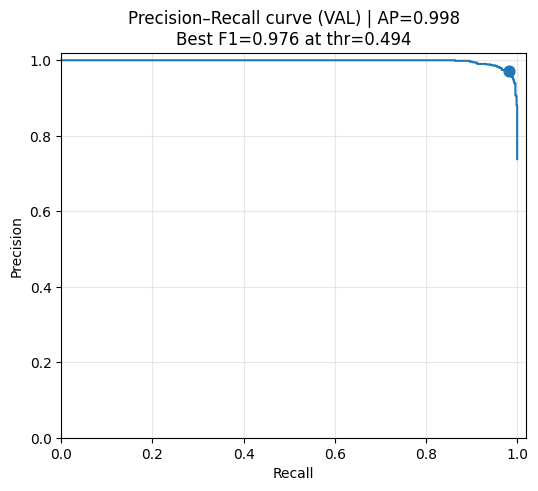

In [ ]:
ap = average_precision_score(val_true, val_probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.scatter(recall[best_i], precision[best_i], s=60)
plt.title(f"Precision–Recall curve (VAL) | AP={ap:.3f}\nBest F1={f1[best_i]:.3f} at thr={best_thr:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.ylim(0, 1.02)
plt.xlim(0, 1.02)
plt.grid(True, alpha=0.3)
plt.show()


Test-set evaluation is performed using the decision threshold selected on the validation set. Threshold-free metrics (AUROC and AUPRC) are first computed from predicted probabilities to assess ranking performance. Error analysis is further supported by explicitly identifying false positives and false negatives at the image level. Results show strong discriminative performance (AUROC 0.985, AUPRC 0.990) and a recall-oriented behavior for the PNEUMONIA class (recall 0.987), minimizing false negatives.



In [ ]:
test_probs, test_true = get_probs_and_labels(test_loader)


print(f"Test AUROC: {roc_auc_score(test_true, test_probs):.4f}")
print(f"Test AUPRC: {average_precision_score(test_true, test_probs):.4f}")



test_pred = (test_probs >= best_thr).astype(int)

# ensure alignment between ImageFolder order and loader order
assert np.all(test_true_from_ds == test_true), "Mismatch between dataset order and loader order!"

FN_idx = np.where((test_true == 1) & (test_pred == 0))[0]
FP_idx = np.where((test_true == 0) & (test_pred == 1))[0]

fn_paths = test_paths[FN_idx]
fp_paths = test_paths[FP_idx]

print(f"FN: {len(FN_idx)} | FP: {len(FP_idx)}")
print("Example FN paths:", fn_paths[:3])
print("Example FP paths:", fp_paths[:3])



test_f1  = f1_score(test_true, test_pred)
test_mcc = matthews_corrcoef(test_true, test_pred)

print(f"Test F1:  {test_f1:.4f}")
print(f"Test MCC: {test_mcc:.4f}")


rep = classification_report(
    test_true,
    test_pred,
    target_names=["NORMAL", "PNEUMONIA"],
    output_dict=True,
    zero_division=0
)

print("\nPer-class metrics (no macro/weighted):")
for cls in ["NORMAL", "PNEUMONIA"]:
    print(
        f"{cls:10s}  "
        f"precision {rep[cls]['precision']:.3f}  "
        f"recall {rep[cls]['recall']:.3f}  "
        f"f1 {rep[cls]['f1-score']:.3f}"
    )


Test AUROC: 0.9848
Test AUPRC: 0.9899
FN: 5 | FP: 36
Example FN paths: ['/content/chest_xray/test/PNEUMONIA/BACTERIA-5757955-0001.jpeg'
 '/content/chest_xray/test/PNEUMONIA/BACTERIA-6833685-0003.jpeg'
 '/content/chest_xray/test/PNEUMONIA/VIRUS-2352342-0001.jpeg']
Example FP paths: ['/content/chest_xray/test/NORMAL/NORMAL-1283091-0001.jpeg'
 '/content/chest_xray/test/NORMAL/NORMAL-1520670-0001.jpeg'
 '/content/chest_xray/test/NORMAL/NORMAL-1627110-0001.jpeg']
Test F1:  0.9494
Test MCC: 0.8611

Per-class metrics (no macro/weighted):
NORMAL      precision 0.975  recall 0.846  f1 0.906
PNEUMONIA   precision 0.914  recall 0.987  f1 0.949


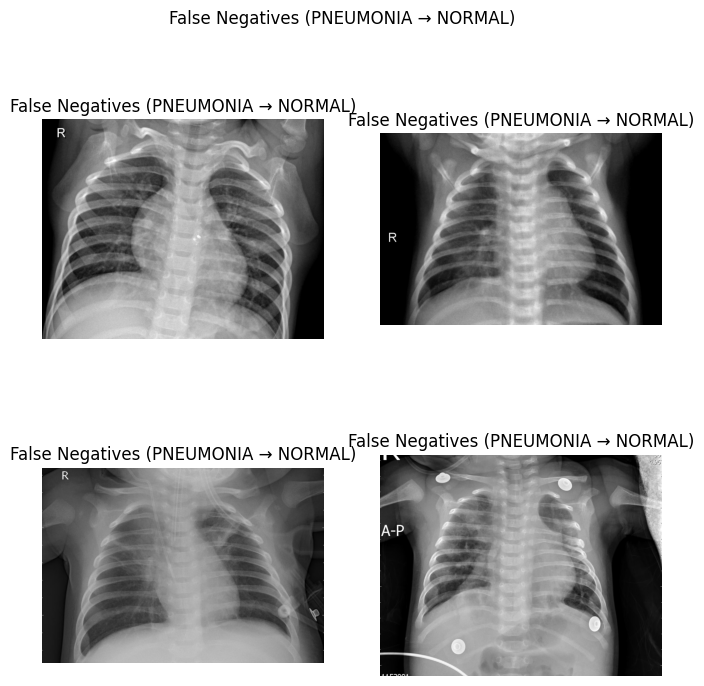

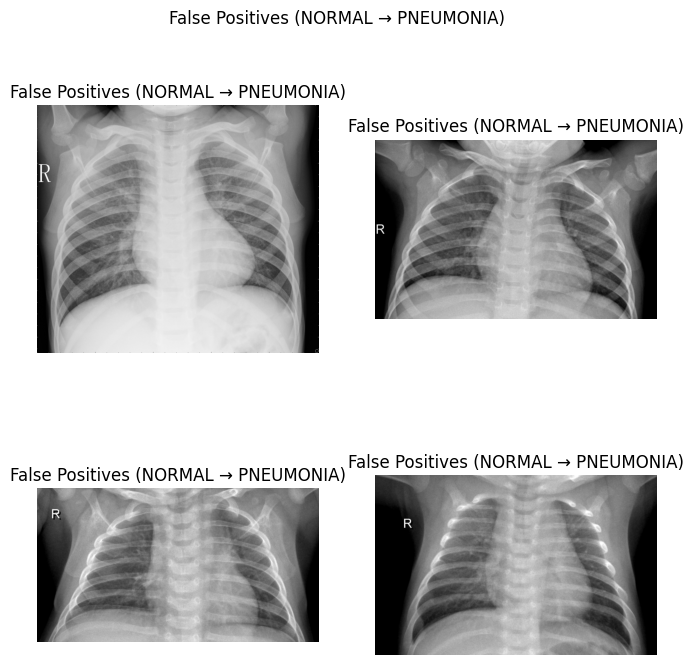

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

def show_paths(paths, title, n=4):
    n = min(n, len(paths))
    if n == 0:
        print(f"No samples to show for {title}")
        return
    plt.figure(figsize=(8, 8))
    for i in range(n):
        img = Image.open(paths[i]).convert("L")
        plt.subplot(2, 2, i+1)
        plt.imshow(img, cmap="gray")
        plt.title(title)
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_paths(fn_paths, "False Negatives (PNEUMONIA → NORMAL)", n=4)
show_paths(fp_paths, "False Positives (NORMAL → PNEUMONIA)", n=4)


The F1-score reported in the Precision–Recall curve corresponds to the optimal F1 achieved on the validation set, while the F1-score printed in the results refers to performance on the independent test set using the selected threshold.

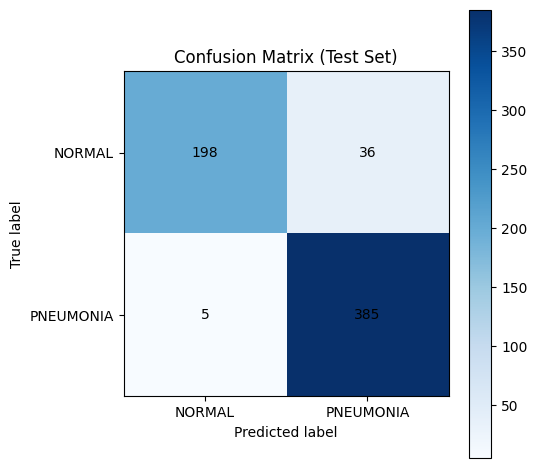

In [ ]:
cm = confusion_matrix(test_true, test_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5.5, 5))

im = ax.imshow(cm, cmap="Blues")

ax.set_title("Confusion Matrix (Test Set)")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks([0, 1], ["NORMAL", "PNEUMONIA"])
ax.set_yticks([0, 1], ["NORMAL", "PNEUMONIA"])

for (r, c), v in np.ndenumerate(cm):
    ax.text(c, r, str(v), ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()



In [ ]:
cm = confusion_matrix(test_true, test_pred)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)


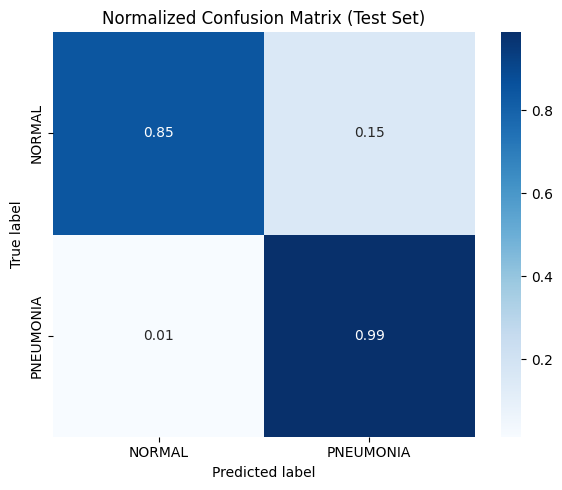

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Normalized Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()


**Considerations**

On the test set, the model achieved strong performance, with an F1-score of 0.949 and an MCC of 0.861. The confusion matrix shows a limited number of misclassifications, with 36 false positives and only 5 false negatives. The decision threshold was selected on the validation set to maximize the F1-score, favoring sensitivity to pneumonia cases. In this setting, accepting a higher number of false positives while keeping false negatives low, can be considered a more precautionary and clinically safer approach.

**Check how far FN and FP are from the threshold**

False negatives are few in number but correspond to cases where the model assigns probabilities well below the decision threshold, indicating confident misclassifications rather than borderline uncertainty. Similarly, false positives exhibit very high predicted probabilities, suggesting that these normal images display strong pneumonia-like patterns according to the learned representation. Overall, misclassifications are not concentrated near the threshold but appear to reflect intrinsically ambiguous or atypical samples rather than threshold instability.

In [ ]:
print("FN probs (sorted):", np.sort(test_probs[FN_idx])[:10])
print("FP probs (sorted):", np.sort(test_probs[FP_idx])[-10:])


FN probs (sorted): [0.12323013 0.1690588  0.2869838  0.35320896 0.4070425 ]
FP probs (sorted): [0.92157835 0.9338821  0.9363745  0.94480306 0.9487693  0.96774274
 0.98122185 0.98348594 0.99364436 0.9992262 ]
